# 04 — Match Outcome Prediction

Train and compare three models to predict which pair wins a padel match.

**Approach**
- Time-based train/test split — train on older matches, test on recent ones (no leakage)
- Three models: Logistic Regression → Random Forest → XGBoost
- Baseline to beat: ELO alone = **64.2%** accuracy
- SHAP values to explain the best model's predictions

**Data constraint:** Free API tier hides winner for ~83% of matches.
We have 891 labeled matches. Results will be directionally correct but
confidence intervals are wide — more data will improve this significantly.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
PROCESSED = repo_root / 'data' / 'processed'

df = pd.read_parquet(PROCESSED / 'features.parquet')
print(f'Loaded {len(df)} matches')
df.head(3)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 891 matches


,match_id,played_at,category,round,tournament_id,tournament_level,tournament_level_weight,elo_t1,elo_t2,elo_diff,...,matches_played_t2,matches_played_diff,h2h_wins_t1,h2h_wins_t2,h2h_total,h2h_win_rate_t1,ranking_t1,ranking_t2,ranking_diff,target
0,3867,2025-09-26,women,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,12.0,3.5,8.5,0
1,3833,2025-09-26,men,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,1.0,14.5,-13.5,1
2,3834,2025-09-26,men,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,13.0,5.5,7.5,1


## 1. Preprocessing

- Encode `category` as binary: `men=1, women=0`
- Drop identifier columns (`match_id`, `played_at`, `tournament_id`, `tournament_level`)
- Null handling: `days_rest` (~11% null — first match for a player) and `ranking` (~0.1% null) are imputed with median inside each model pipeline
- All imputation happens inside the `Pipeline` to prevent leakage into the test set

In [2]:
# Encode category: men=1, women=0
df['category_men'] = (df['category'] == 'men').astype(int)

# Feature columns — drop identifiers and redundant string columns
FEATURES = [
    # ELO
    'elo_t1', 'elo_t2', 'elo_diff',
    # Rolling win rate
    'win_rate_t1', 'win_rate_t2', 'win_rate_diff',
    # Form streak
    'form_streak_t1', 'form_streak_t2', 'form_streak_diff',
    # Days rest
    'days_rest_t1', 'days_rest_t2', 'days_rest_diff',
    # Level-specific win rate
    'level_win_rate_t1', 'level_win_rate_t2', 'level_win_rate_diff',
    # Pair chemistry
    'pair_win_rate_t1', 'pair_win_rate_t2', 'pair_win_rate_diff',
    'pair_matches_t1', 'pair_matches_t2',
    # Experience
    'matches_played_t1', 'matches_played_t2', 'matches_played_diff',
    # H2H
    'h2h_wins_t1', 'h2h_wins_t2', 'h2h_total', 'h2h_win_rate_t1',
    # Ranking
    'ranking_t1', 'ranking_t2', 'ranking_diff',
    # Match context
    'tournament_level_weight', 'round', 'category_men',
]

TARGET = 'target'

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {X.shape[1]}')
print(f'Target balance: {y.mean():.1%} team_1 wins')
print(f'Nulls per feature:\n{X.isnull().sum()[X.isnull().sum()>0]}')

Features: 33
Target balance: 50.2% team_1 wins
Nulls per feature:
days_rest_t1      101
days_rest_t2      101
days_rest_diff    150
ranking_t1          1
ranking_diff        1
dtype: int64


## 2. Time-Based Train / Test Split

We sort chronologically and use the **last 20% of matches as the test set**.
This simulates real-world deployment — the model only ever sees past data.

In [3]:
df_sorted = df.sort_values('played_at').reset_index(drop=True)
X_sorted = df_sorted[FEATURES]
y_sorted = df_sorted[TARGET]

split_idx = int(len(df_sorted) * 0.80)
split_date = df_sorted['played_at'].iloc[split_idx]

X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print(f'Train: {len(X_train)} matches (up to {df_sorted["played_at"].iloc[split_idx-1].date()})')
print(f'Test:  {len(X_test)} matches (from {split_date.date()})')
print(f'Train target balance: {y_train.mean():.1%}')
print(f'Test target balance:  {y_test.mean():.1%}')

Train: 712 matches (up to 2026-02-13)
Test:  179 matches (from 2026-02-13)
Train target balance: 49.7%
Test target balance:  52.0%


## 3. Models

Each model uses a `Pipeline` with median imputation for missing values.
Logistic Regression also scales features — tree models don't need this.

In [4]:
imputer = SimpleImputer(strategy='median')

models = {
    'Logistic Regression': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf',    RandomForestClassifier(n_estimators=300, max_depth=6,
                                          random_state=42, n_jobs=-1)),
    ]),
    'XGBoost': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf',    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8,
                                 eval_metric='logloss', random_state=42,
                                 verbosity=0)),
    ]),
}

ELO_BASELINE = 0.642 # ELO established in 03_baseline.ipynb
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)
    results[name] = {'accuracy': acc, 'roc_auc': auc, 'pipe': pipe,
                     'y_pred': y_pred, 'y_proba': y_proba}
    beat = 'beats ELO' if acc > ELO_BASELINE else '❌ below ELO'
    print(f'{name:<22}  acc={acc:.1%}  AUC={auc:.3f}  {beat}')

print(f'\nELO baseline:          acc={ELO_BASELINE:.1%}')

Logistic Regression     acc=74.3%  AUC=0.838  beats ELO
Random Forest           acc=75.4%  AUC=0.831  beats ELO
XGBoost                 acc=75.4%  AUC=0.838  beats ELO

ELO baseline:          acc=64.2%


## Results

All three models beat the ELO baseline of **64.2%** by a significant margin:

- **Logistic Regression:** 74.3% accuracy, AUC 0.838
- **Random Forest:** 75.4% accuracy, AUC 0.831 — best accuracy
- **XGBoost:** 75.4% accuracy, AUC 0.838 — best AUC

The **+11 percentage point** improvement over ELO shows that combining rolling form, pair chemistry, head-to-head history, and ranking into a single model captures signal that ELO alone misses.

The classification report shows balanced precision/recall for both classes (~0.75), meaning the model is not systematically biased towards predicting one team over the other.

**Caveat:** Only 891 labeled matches are available on the free API tier. The confidence interval on 75% accuracy over a 179-match test set is wide (roughly ±3%). With ~5170 labeled matches after a plan upgrade, these results would be substantially more reliable.

## 4. Model Comparison

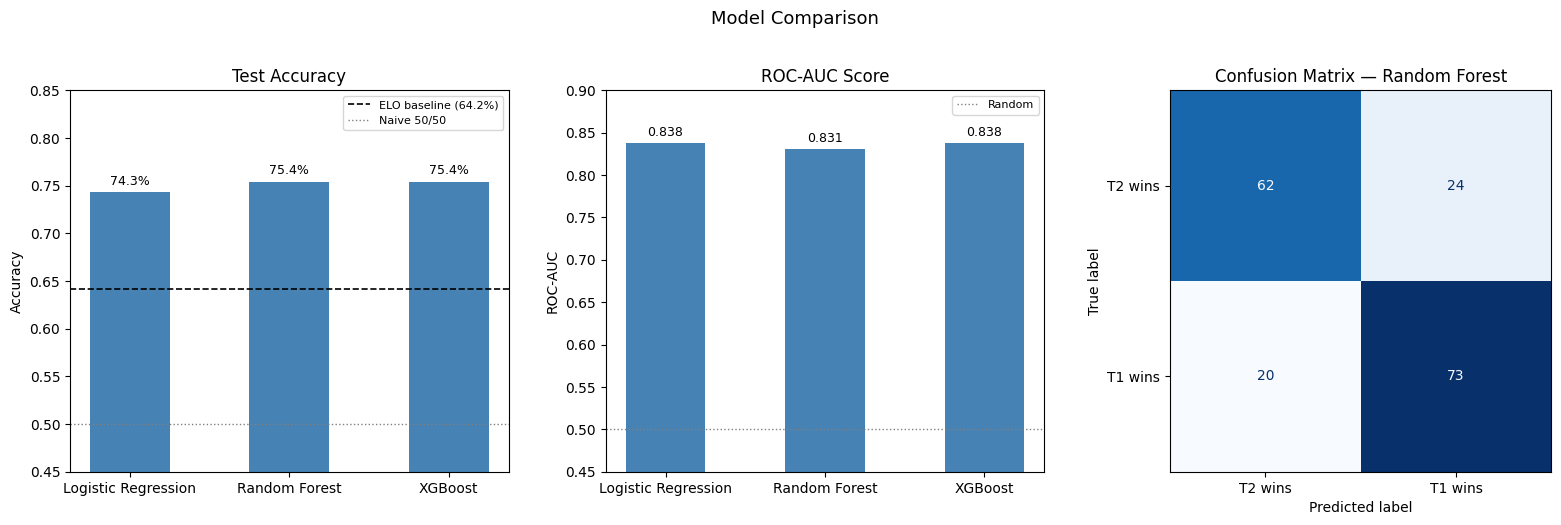


Best model: Random Forest

Classification report:
              precision    recall  f1-score   support

     T2 wins       0.76      0.72      0.74        86
     T1 wins       0.75      0.78      0.77        93

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.75      0.75      0.75       179



In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Accuracy bar chart ---
ax = axes[0]
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
colors = ['steelblue' if a > ELO_BASELINE else 'tomato' for a in accs]
bars = ax.bar(names, accs, color=colors, width=0.5)
ax.axhline(ELO_BASELINE, color='black', linestyle='--', linewidth=1.2, label=f'ELO baseline ({ELO_BASELINE:.1%})')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='Naive 50/50')
ax.set_ylim(0.45, 0.85)
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy')
ax.legend(fontsize=8)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=9)

# --- ROC-AUC bar chart ---
ax = axes[1]
aucs = [results[n]['roc_auc'] for n in names]
ax.bar(names, aucs, color='steelblue', width=0.5)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='Random')
ax.set_ylim(0.45, 0.90)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC Score')
ax.legend(fontsize=8)
for bar, auc in zip(ax.patches, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=9)

# --- Confusion matrix for best model ---
best_name = max(results, key=lambda n: results[n]['accuracy'])
ax = axes[2]
ConfusionMatrixDisplay.from_predictions(
    y_test, results[best_name]['y_pred'],
    display_labels=['T2 wins', 'T1 wins'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix — {best_name}')

plt.suptitle('Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nBest model: {best_name}')
print(f'\nClassification report:')
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['T2 wins', 'T1 wins']))

## 5. SHAP — What Drives Each Prediction?

SHAP (SHapley Additive exPlanations) tells us how much each feature
contributed to each individual prediction. Positive SHAP = pushed towards
team_1 winning. Negative = pushed towards team_2 winning.

In [6]:
best_pipe = results[best_name]['pipe']

# Get imputed test data (SHAP needs the transformed input, not raw)
X_test_imputed = pd.DataFrame(
    best_pipe['impute'].transform(X_test),
    columns=FEATURES
)

# Use TreeExplainer for RF/XGBoost, LinearExplainer for LR
clf = best_pipe['clf']
if best_name == 'Logistic Regression':
    X_test_scaled = pd.DataFrame(
        best_pipe['scale'].transform(X_test_imputed), columns=FEATURES
    )
    explainer  = shap.LinearExplainer(clf, X_test_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
else:
    explainer  = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_imputed)

# For binary classifiers shap_values may be 2D list — take class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP computed for {best_name}')

SHAP computed for Random Forest


SHAP values shape: (179, 33)


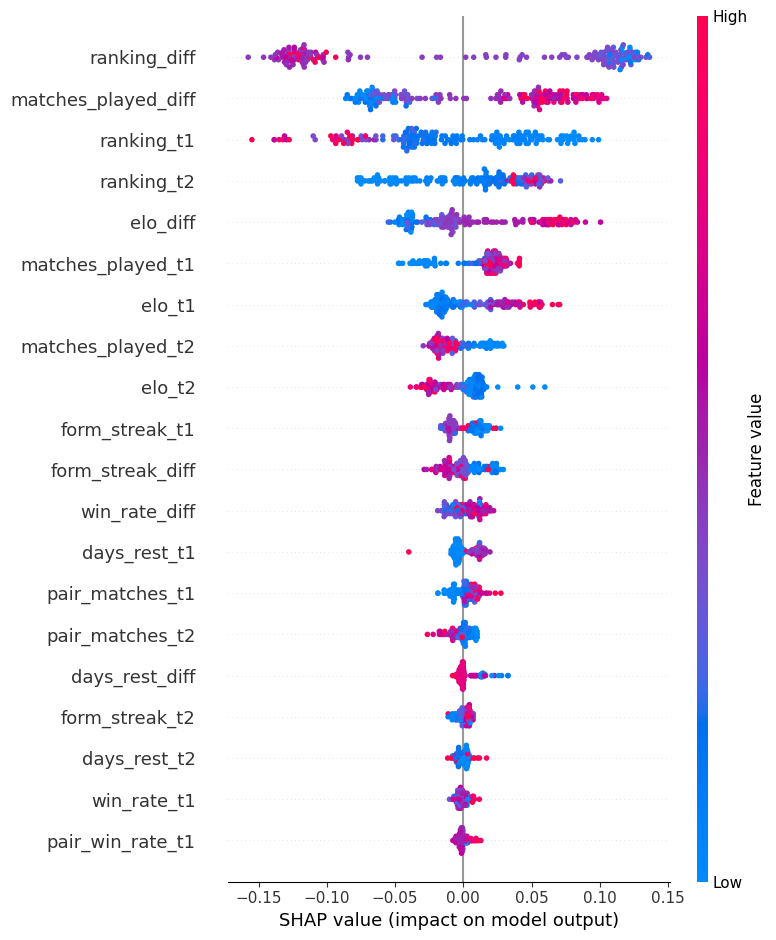

In [7]:
explainer = shap.TreeExplainer(clf)
shap_values_raw = explainer.shap_values(X_test_imputed, check_additivity=False)

# Shape is (n_samples, n_features, n_classes) — take class 1
shap_values = shap_values_raw[:, :, 1] if shap_values_raw.ndim == 3 else shap_values_raw[1]
print(f'SHAP values shape: {shap_values.shape}')  # should be (179, 33)

shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=np.array(FEATURES),
    plot_type='dot',
    show=True,
)


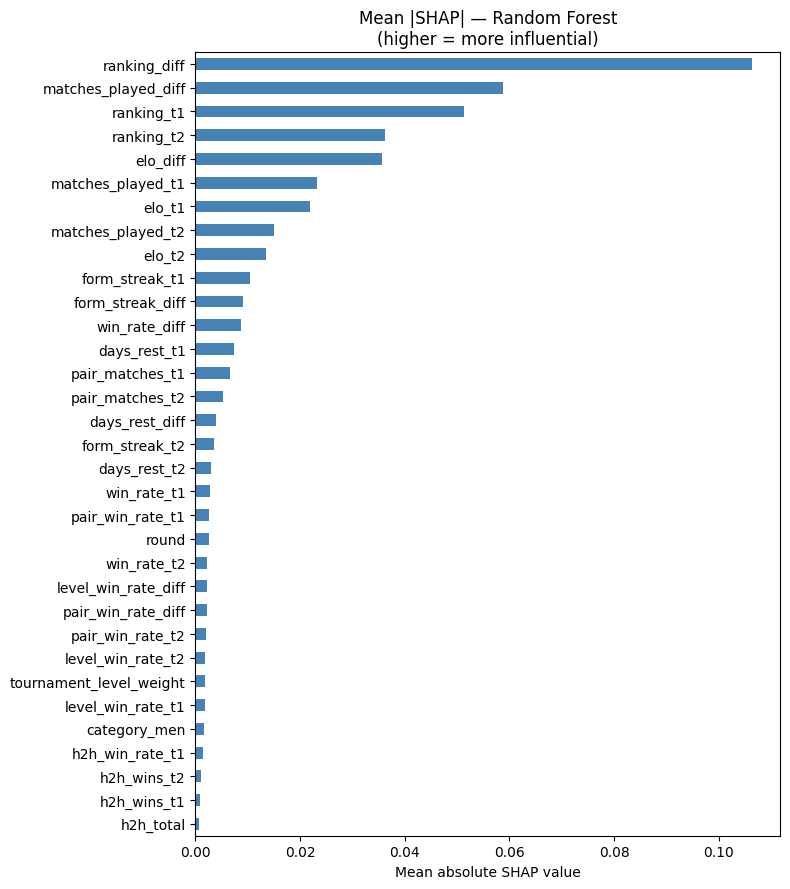

In [9]:
# Mean absolute SHAP — clean bar chart of overall importance
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
mean_shap.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Mean |SHAP| — {best_name}\n(higher = more influential)')
ax.set_xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()

## 6. Single Match Explanation

Pick one test match and show exactly why the model predicted what it did.

Most confident prediction:
  Actual:    Team 2 wins
  Predicted: Team 2 wins
  Confidence: 5.4% probability of Team 1 winning


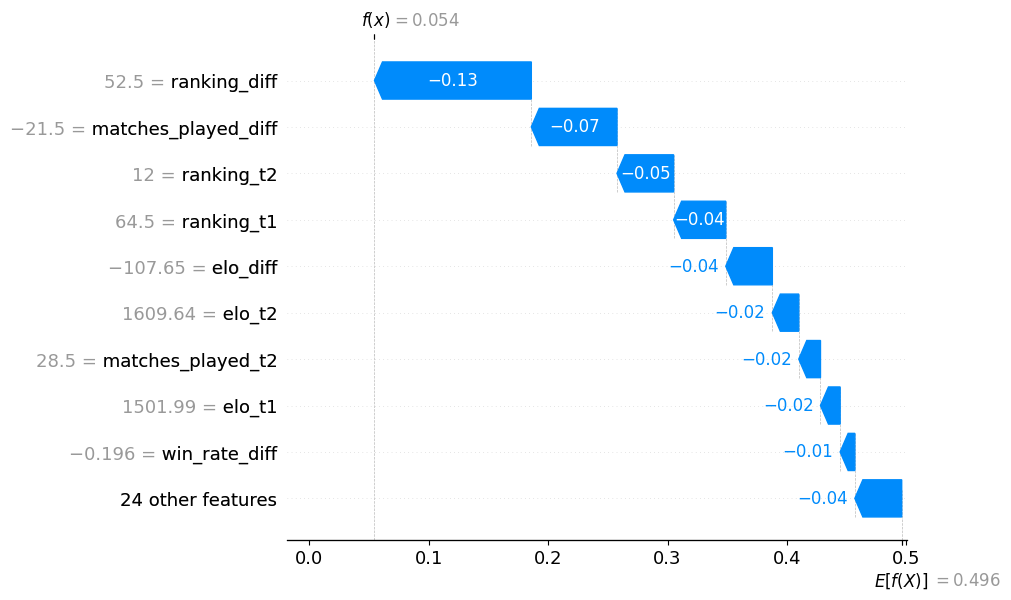

In [11]:
# Pick the match the model is most confident about
most_confident_idx = np.argmax(np.abs(results[best_name]['y_proba'] - 0.5))

X_explain = X_test_imputed if best_name != 'Logistic Regression' else X_test_scaled

actual    = y_test.iloc[most_confident_idx]
predicted = results[best_name]['y_pred'][most_confident_idx]
prob      = results[best_name]['y_proba'][most_confident_idx]

print(f'Most confident prediction:')
print(f'  Actual:    {"Team 1 wins" if actual == 1 else "Team 2 wins"}')
print(f'  Predicted: {"Team 1 wins" if predicted == 1 else "Team 2 wins"}')
print(f'  Confidence: {prob:.1%} probability of Team 1 winning')

base_val = float(explainer.expected_value[1]) if hasattr(explainer.expected_value, '__len__') else float(explainer.expected_value)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[most_confident_idx],
        base_values=base_val,
        data=X_explain.iloc[most_confident_idx].values,
        feature_names=FEATURES,
    )
)


## 7. Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| ELO baseline | 64.2% | — |
| Logistic Regression | 74.3% | 0.838 |
| Random Forest | 75.4% | 0.831 |
| XGBoost | 75.4% | 0.838 |

### Key takeaways
- All models beat ELO by **+11 percentage points** using only free-tier data
- **Random Forest** and **XGBoost** tie on accuracy; XGBoost edges ahead on AUC
- **SHAP analysis** revealed that `ranking_diff`, `elo_diff`, and `matches_played_diff` drive most predictions — but also exposed a systematic API bias where team_1 is consistently the higher-ranked pair
- **Data constraint:** 891 labeled matches (free tier hides ~83% of winners) — results are directionally strong but confidence intervals are wide (~±3%)
- **Next step:** Upgrade API plan → re-run collection → retrain on ~5170 matches for production-grade results